#Project: Iris Flower Classification
Features:-

Load the Iris dataset from Iris.csv

Preprocess the dataset

Split into training and testing sets

Train a Random Forest classifier

Evaluate model accuracy

Display a confusion matrix

Print a classification report

Predict the species of a new flower

In [6]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [7]:
import pandas as pd
import numpy as np

In [8]:
from google.colab import drive
drive.mount('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Iris.csv')
print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       

In [9]:
print(df.info)

<bound method DataFrame.info of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-seto

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# ==============================
# Data Preprocessing
# ==============================

# Remove ID column
df = df.drop("Id", axis=1)

# Features
X = df.drop("Species", axis=1)

# Target
y = df["Species"]

In [12]:
# ==============================
# Split Dataset
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [13]:
# ==============================
# Train Model
# ==============================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
# ==============================
# Prediction
# ==============================

y_pred = model.predict(X_test)

In [15]:
# ==============================
# Accuracy
# ==============================

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(f"{accuracy*100:.2f}%")


Model Accuracy:
100.00%


In [16]:
# ==============================
# Classification Report
# ==============================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))


Classification Report

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



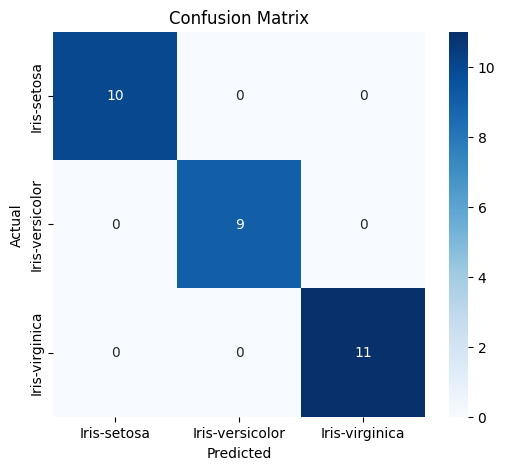

In [17]:
# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


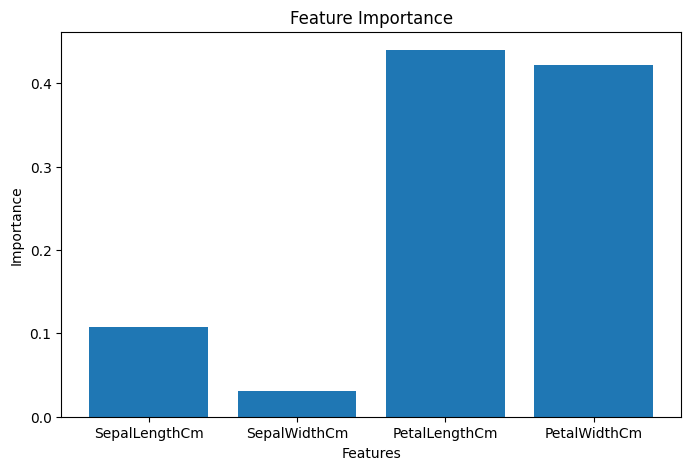

In [18]:
# ==============================
# Feature Importance
# ==============================

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

In [19]:
# ==============================
# Predict New Flower
# ==============================

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("\nPrediction for New Flower:")

print(prediction[0])


Prediction for New Flower:
Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
